# ERCOT Energy Procurement Value Analysis

**Objective:** Quantify the dollar savings a utility serving the ERCOT (Texas) grid would realize by using our bias-correction neural network instead of raw NWP ensemble mean forecasts for day-ahead electricity procurement.

**Methodology:**
1. Map model cities to ERCOT load centers (Houston, Dallas, San Antonio, Austin)
2. Population-weight city forecasts to get an ERCOT-wide temperature
3. Compute load forecast error = (forecast - actual) x sensitivity (MW/degF)
4. Cost of error = |load_error| x DA-RT spread x peak hours
5. Savings = NWP cost - NN cost

## 1. Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

# Use a clean style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
    "legend.fontsize": 10,
})

# Project imports
from energy_value import (
    run_ercot_analysis, build_ercot_daily, sensitivity_analysis,
    load_real_ercot_prices,
    ERCOT_CITIES, DEFAULT_SENSITIVITY_MW_PER_F, DEFAULT_COOLING_THRESHOLD_F,
    PEAK_HOURS,
)
from economic_data_prep import load_test_with_nwp
import config as cfg

# Dollar formatter for y-axes
def dollar_fmt(x, _):
    if abs(x) >= 1e6:
        return f"${x / 1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x / 1e3:.0f}K"
    return f"${x:.0f}"

print("Imports loaded successfully.")
print(f"Test period: {cfg.TEST_START} to {cfg.TEST_END}")

Imports loaded successfully.
Test period: 2025-04-17 to 2026-04-16


In [2]:
# Load test data with NWP forecasts
df = load_test_with_nwp()
print(f"Full dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Cities: {df['ticker'].nunique()}")
print(f"ERCOT cities present: {[t for t in ERCOT_CITIES if t in df['ticker'].unique()]}")

Full dataset shape: (7300, 12)
Date range: 2025-04-17 to 2026-04-16
Cities: 20
ERCOT cities present: ['KXHIGHTHOU', 'KXHIGHTDAL', 'KXHIGHTSATX', 'KXHIGHAUS']


## 2. ERCOT City Mapping

The four ERCOT load centers are population-weighted to approximate grid-wide temperature exposure.

| City | Ticker | Population Weight | Rationale |
|------|--------|:-----------------:|-----------|
| Houston | `KXHIGHTHOU` | 0.35 | Largest metro, highest load share |
| Dallas | `KXHIGHTDAL` | 0.30 | Second-largest metro |
| San Antonio | `KXHIGHTSATX` | 0.20 | Third-largest |
| Austin | `KXHIGHAUS` | 0.15 | Smallest of the four |

Weights sum to 1.0. The population-weighted average temperature is used as the ERCOT-wide forecast.

In [3]:
# Display city mapping programmatically
city_names = {
    "KXHIGHTHOU": "Houston",
    "KXHIGHTDAL": "Dallas",
    "KXHIGHTSATX": "San Antonio",
    "KXHIGHAUS": "Austin",
}
mapping_df = pd.DataFrame([
    {"City": city_names[t], "Ticker": t, "Weight": w}
    for t, w in ERCOT_CITIES.items()
])
print(f"Total weight: {mapping_df['Weight'].sum():.2f}")
mapping_df

Total weight: 1.00


,City,Ticker,Weight
0,Houston,KXHIGHTHOU,0.35
1,Dallas,KXHIGHTDAL,0.30
2,San Antonio,KXHIGHTSATX,0.20
3,Austin,KXHIGHAUS,0.15


## 3. Run ERCOT Analysis

In [4]:
# Run the full ERCOT analysis with real ERCOT HB_HOUSTON prices
daily = run_ercot_analysis(df)
print(f"Daily results shape: {daily.shape}")
print(f"Columns: {daily.columns.tolist()}")

# Show real price stats
print(f"\nDA-RT spread (real ERCOT HB_HOUSTON peak-hour):")
print(f"  Mean:   ${daily['da_rt_spread'].mean():.2f}/MWh")
print(f"  Median: ${daily['da_rt_spread'].median():.2f}/MWh")
print(f"  Std:    ${daily['da_rt_spread'].std():.2f}/MWh")
print(f"  Range:  ${daily['da_rt_spread'].min():.2f} to ${daily['da_rt_spread'].max():.2f}/MWh")
print()
daily.head(10)

Daily results shape: (365, 15)
Columns: ['date', 'nn_forecast', 'nwp_forecast', 'actual', 'nn_sigma', 'month', 'nn_load_error_mw', 'nwp_load_error_mw', 'da_rt_spread', 'dam_price_avg', 'rtm_price_avg', 'nn_cost', 'nwp_cost', 'daily_savings', 'cumulative_savings']

DA-RT spread (real ERCOT HB_HOUSTON peak-hour):
  Mean:   $2.86/MWh
  Median: $3.29/MWh
  Std:    $25.30/MWh
  Range:  $-228.07 to $304.09/MWh



,date,nn_forecast,nwp_forecast,actual,nn_sigma,month,nn_load_error_mw,nwp_load_error_mw,da_rt_spread,dam_price_avg,rtm_price_avg,nn_cost,nwp_cost,daily_savings,cumulative_savings
0,2025-04-17,86.191401,85.426667,86.80,0.679864,4,-304.299296,-686.666667,18.840312,44.55750,25.717188,45864.750588,103496.116667,57631.366079,57631.366079
1,2025-04-18,88.837949,87.592500,89.00,0.676476,4,-81.025744,-703.750000,11.578125,44.03875,32.460625,7505.009545,65184.843750,57679.834205,115311.200284
2,2025-04-19,81.579406,81.622500,82.15,0.800971,4,-285.296949,-263.750000,9.520938,28.66000,19.139063,21730.355397,20089.178125,-1641.177272,113670.023012
3,2025-04-20,83.276487,81.671667,83.40,0.787295,4,-61.756569,-864.166667,10.716563,43.63375,32.917187,5294.545073,74087.168750,68792.623677,182462.646689
4,2025-04-21,84.057601,82.011667,85.15,0.714886,4,-546.199251,-1569.166667,4.121563,35.21625,31.094687,18009.554791,51739.347917,33729.793126,216192.439814
5,2025-04-22,86.632872,84.522500,87.15,0.722230,4,-258.563943,-1313.750000,-13.409688,41.17375,54.583438,27738.093385,140935.815625,113197.722240,329390.162054
6,2025-04-23,80.936226,80.317500,80.35,0.743179,4,293.112929,-16.250000,6.123437,33.63500,27.511563,14358.869588,796.046875,-13562.822713,315827.339341
7,2025-04-24,81.026093,80.240833,80.90,0.793197,4,63.046505,-329.583333,9.657812,40.78625,31.128438,4871.130566,25464.432292,20593.301726,336420.641066
8,2025-04-25,84.462487,82.875833,85.05,0.748857,4,-293.756687,-1087.083333,18.562500,46.22000,27.657500,43622.868056,161431.875000,117809.006944,454229.648010
9,2025-04-26,85.414535,83.561667,84.90,0.767557,4,257.267379,-669.166667,-5.030000,34.88000,39.910000,10352.439346,26927.266667,16574.827321,470804.475332


## 4. Summary Statistics

In [5]:
# --- Key metrics ---

# Temperature MAE (ERCOT-wide, population-weighted)
nn_mae = np.abs(daily["nn_forecast"] - daily["actual"]).mean()
nwp_mae = np.abs(daily["nwp_forecast"] - daily["actual"]).mean()

# Per-city MAE for ERCOT cities
ercot_df = df[df["ticker"].isin(ERCOT_CITIES)].copy()
city_mae = ercot_df.groupby("ticker").apply(
    lambda g: pd.Series({
        "NN MAE (F)": np.abs(g["mu"] - g["y_true"]).mean(),
        "NWP MAE (F)": np.abs(g["nwp_ensemble_mean"] - g["y_true"]).mean(),
    }),
    include_groups=False,
)
city_names = {
    "KXHIGHTHOU": "Houston", "KXHIGHTDAL": "Dallas",
    "KXHIGHTSATX": "San Antonio", "KXHIGHAUS": "Austin",
}
city_mae["City"] = city_mae.index.map(city_names)
city_mae["Improvement (F)"] = city_mae["NWP MAE (F)"] - city_mae["NN MAE (F)"]
print("Temperature MAE by ERCOT City:")
print(city_mae[["City", "NN MAE (F)", "NWP MAE (F)", "Improvement (F)"]].to_string(index=False))

print(f"\n--- ERCOT-Wide (Population-Weighted) ---")
print(f"NN temperature MAE:   {nn_mae:.2f} degF")
print(f"NWP temperature MAE:  {nwp_mae:.2f} degF")
print(f"MAE improvement:      {nwp_mae - nn_mae:.2f} degF ({(nwp_mae - nn_mae) / nwp_mae * 100:.1f}%)")

# Annual costs & savings
nn_total_cost = daily["nn_cost"].sum()
nwp_total_cost = daily["nwp_cost"].sum()
total_savings = daily["daily_savings"].sum()
total_days = len(daily)
positive_days = (daily["daily_savings"] > 0).sum()

print(f"\n--- Annual Procurement Costs (Real ERCOT Prices) ---")
print(f"Price source:     ERCOT HB_HOUSTON peak-hour (HE 13-20) settlement prices")
print(f"NN annual cost:   ${nn_total_cost:>12,.0f}")
print(f"NWP annual cost:  ${nwp_total_cost:>12,.0f}")
print(f"Annual savings:   ${total_savings:>12,.0f}")

print(f"\n--- Savings Frequency ---")
print(f"Days with positive savings: {positive_days}/{total_days} ({positive_days/total_days*100:.1f}%)")
print(f"Average daily savings:      ${total_savings / total_days:>10,.0f}")

# Summer vs non-summer
summer = daily[(daily["month"] >= 6) & (daily["month"] <= 9)]
non_summer = daily[~((daily["month"] >= 6) & (daily["month"] <= 9))]

print(f"\n--- Seasonal Breakdown ---")
print(f"Summer (Jun-Sep) savings:    ${summer['daily_savings'].sum():>12,.0f}  ({len(summer)} days)")
print(f"Non-summer savings:          ${non_summer['daily_savings'].sum():>12,.0f}  ({len(non_summer)} days)")

Temperature MAE by ERCOT City:
       City  NN MAE (F)  NWP MAE (F)  Improvement (F)
     Austin    1.116655     2.622603         1.505947
     Dallas    0.986151     1.525708         0.539557
    Houston    1.528141     2.549087         1.020946
San Antonio    1.151731     1.402009         0.250278

--- ERCOT-Wide (Population-Weighted) ---
NN temperature MAE:   0.69 degF
NWP temperature MAE:  1.73 degF
MAE improvement:      1.04 degF (59.9%)

--- Annual Procurement Costs (Real ERCOT Prices) ---
Price source:     ERCOT HB_HOUSTON peak-hour (HE 13-20) settlement prices
NN annual cost:   $   8,179,437
NWP annual cost:  $  23,499,437
Annual savings:   $  15,320,000

--- Savings Frequency ---
Days with positive savings: 303/365 (83.0%)
Average daily savings:      $    41,973

--- Seasonal Breakdown ---
Summer (Jun-Sep) savings:    $   5,712,321  (122 days)
Non-summer savings:          $   9,607,679  (243 days)


## 5. Cumulative Savings Over Time

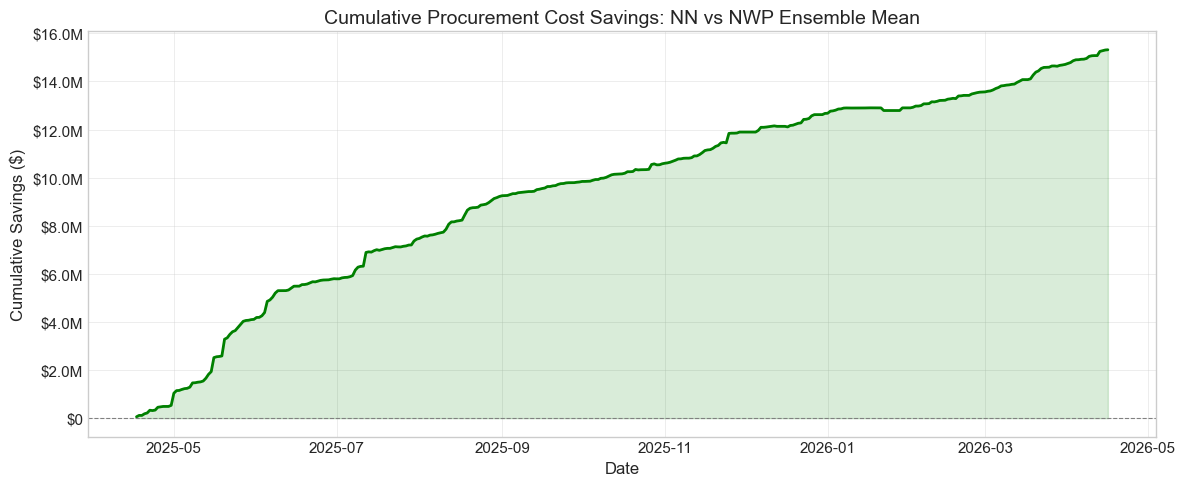

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily["date"], daily["cumulative_savings"], color="green", lw=2)
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.fill_between(daily["date"], 0, daily["cumulative_savings"],
                where=daily["cumulative_savings"] >= 0, alpha=0.15, color="green")
ax.fill_between(daily["date"], 0, daily["cumulative_savings"],
                where=daily["cumulative_savings"] < 0, alpha=0.15, color="red")
ax.set_title("Cumulative Procurement Cost Savings: NN vs NWP Ensemble Mean")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Savings ($)")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
fig.tight_layout()
plt.show()

## 6. Daily Load Error Comparison

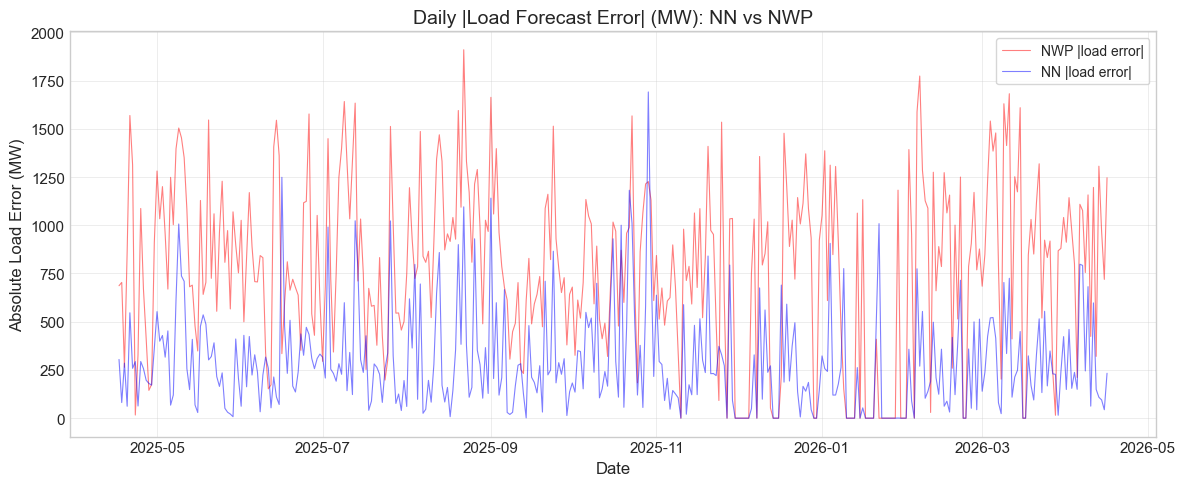

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily["date"], daily["nwp_load_error_mw"].abs(), alpha=0.5,
        label="NWP |load error|", color="red", lw=0.8)
ax.plot(daily["date"], daily["nn_load_error_mw"].abs(), alpha=0.5,
        label="NN |load error|", color="blue", lw=0.8)
ax.set_title("Daily |Load Forecast Error| (MW): NN vs NWP")
ax.set_xlabel("Date")
ax.set_ylabel("Absolute Load Error (MW)")
ax.legend(frameon=True, fancybox=True)
fig.tight_layout()
plt.show()

## 7. Monthly Savings

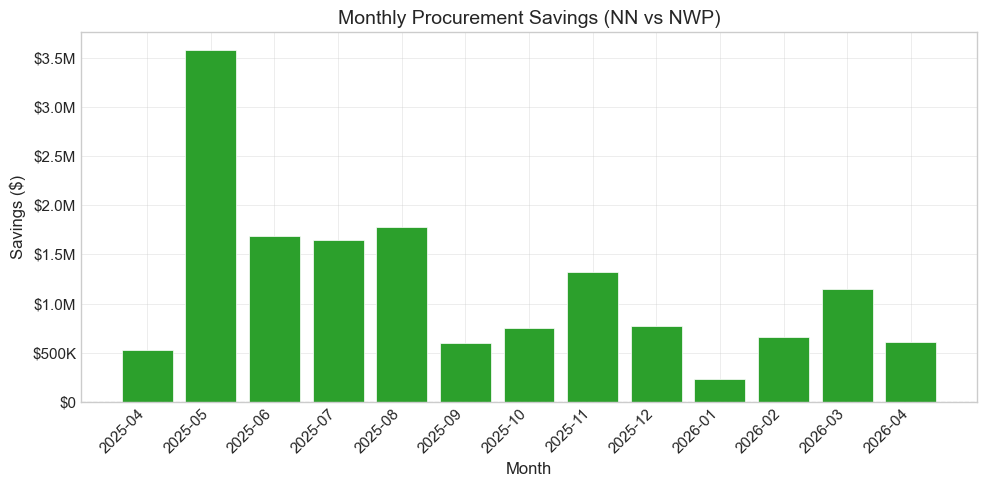

In [8]:
monthly = daily.groupby(daily["date"].dt.to_period("M"))["daily_savings"].sum()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in monthly.values]
bars = ax.bar(range(len(monthly)), monthly.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels([str(p) for p in monthly.index], rotation=45, ha="right")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_title("Monthly Procurement Savings (NN vs NWP)")
ax.set_xlabel("Month")
ax.set_ylabel("Savings ($)")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
fig.tight_layout()
plt.show()

## 8. Savings vs Temperature (Cooling Days)

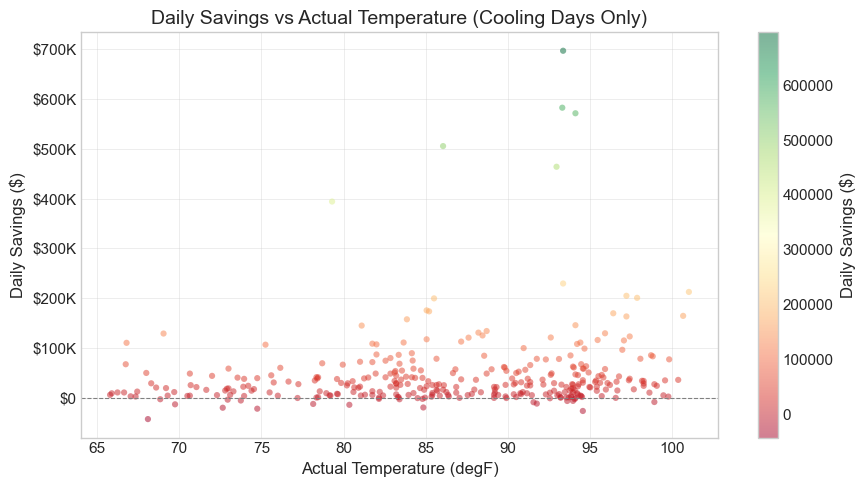

Cooling days (actual > 65.0 degF): 326/365


In [9]:
cooling_days = daily[daily["actual"] > DEFAULT_COOLING_THRESHOLD_F]

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(cooling_days["actual"], cooling_days["daily_savings"],
                alpha=0.5, s=20, c=cooling_days["daily_savings"],
                cmap="RdYlGn", edgecolors="none")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Actual Temperature (degF)")
ax.set_ylabel("Daily Savings ($)")
ax.set_title("Daily Savings vs Actual Temperature (Cooling Days Only)")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
plt.colorbar(sc, ax=ax, label="Daily Savings ($)")
fig.tight_layout()
plt.show()

print(f"Cooling days (actual > {DEFAULT_COOLING_THRESHOLD_F} degF): {len(cooling_days)}/{len(daily)}")

## 9. Error Distribution: NN vs NWP

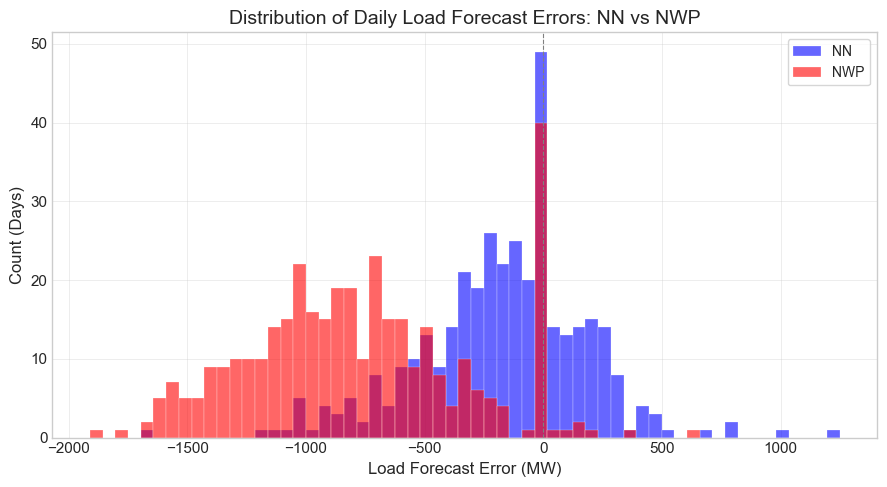

NN  load error std:       356 MW
NWP load error std:       462 MW


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(
    min(daily["nn_load_error_mw"].min(), daily["nwp_load_error_mw"].min()),
    max(daily["nn_load_error_mw"].max(), daily["nwp_load_error_mw"].max()),
    60,
)
ax.hist(daily["nn_load_error_mw"], bins=bins, alpha=0.6, label="NN", color="blue", edgecolor="white", linewidth=0.3)
ax.hist(daily["nwp_load_error_mw"], bins=bins, alpha=0.6, label="NWP", color="red", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Load Forecast Error (MW)")
ax.set_ylabel("Count (Days)")
ax.set_title("Distribution of Daily Load Forecast Errors: NN vs NWP")
ax.legend(frameon=True, fancybox=True)
fig.tight_layout()
plt.show()

print(f"NN  load error std:  {daily['nn_load_error_mw'].std():>8,.0f} MW")
print(f"NWP load error std:  {daily['nwp_load_error_mw'].std():>8,.0f} MW")

## 10. Sensitivity Analysis

Annual savings across a range of temperature-load sensitivities (MW/degF), all using real ERCOT prices.

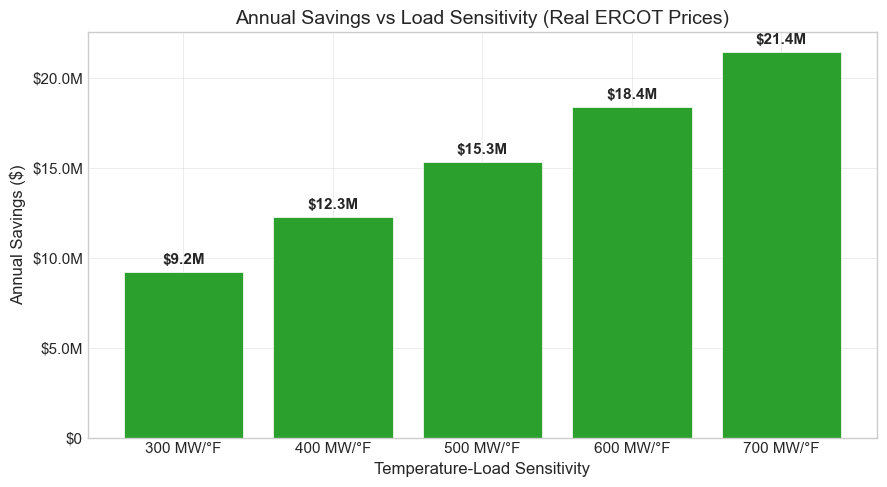


Sensitivity results:
   300 MW/°F: $   9,192,000
   400 MW/°F: $  12,256,000
   500 MW/°F: $  15,320,000  <-- base case
   600 MW/°F: $  18,384,000
   700 MW/°F: $  21,448,000


In [11]:
# Run sensitivity analysis (real prices, varying MW/°F only)
sens_df = sensitivity_analysis(df)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    [f"{int(s)} MW/°F" for s in sens_df["sensitivity_mw_per_f"]],
    sens_df["annual_savings"],
    color="#2ca02c", edgecolor="white", linewidth=0.5,
)
for i, val in enumerate(sens_df["annual_savings"]):
    ax.text(i, val + sens_df["annual_savings"].max() * 0.02,
            f"${val / 1e6:.1f}M", ha="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Temperature-Load Sensitivity")
ax.set_ylabel("Annual Savings ($)")
ax.set_title("Annual Savings vs Load Sensitivity (Real ERCOT Prices)")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
fig.tight_layout()
plt.show()

print("\nSensitivity results:")
for _, row in sens_df.iterrows():
    marker = "  <-- base case" if row["sensitivity_mw_per_f"] == 500 else ""
    print(f"  {int(row['sensitivity_mw_per_f']):>4} MW/°F: ${row['annual_savings']:>12,.0f}{marker}")

## 11. Parameter Assumptions

### Core Parameters

| Parameter | Value | Source / Rationale |
|-----------|-------|-------------------|
| **DA-RT spread** | Real ERCOT HB_HOUSTON settlement prices | Downloaded from ERCOT MIS (reportTypeId 13060/13061). Peak hours HE 13-20. No simulated or assumed spreads. |
| **Temperature-load sensitivity** | 500 MW/degF | ERCOT CDR reports; Considine (2000); Sailor & Munoz (1997). Represents the incremental MW of load per degree F above the cooling threshold. |
| **Cooling threshold** | 65 degF | Standard cooling degree day (CDD) base temperature. AC load ramps above this point. |
| **Peak hours** | 8 hours/day (HE 13-20) | Standard ERCOT peak window when temperature drives load. |
| **Population weights** | Houston 0.35, Dallas 0.30, San Antonio 0.20, Austin 0.15 | Proportional to metro population / load share in ERCOT. |

### Key Assumptions

1. **Real electricity prices** -- all DA-RT spreads come from actual ERCOT settlement data. No simulated or assumed price spreads are used.
2. **Linear temperature-demand relationship** above the cooling threshold. Real demand curves are slightly nonlinear, but the linear approximation is standard in the literature.
3. **Price-taking utility** -- the utility's procurement change does not affect wholesale prices.
4. **Only daily max temperature** -- real load forecasting uses hourly profiles, humidity, etc. Our analysis isolates the temperature channel only.
5. **Population-weighted city average approximates ERCOT-wide temperature** -- a simplification; ERCOT spans all of Texas.
6. **No capacity market or ancillary service value** -- only energy procurement savings are counted.
7. **Symmetric cost of error** -- both over- and under-forecasting incur costs.

### Data Sources

| Source | Description |
|--------|-------------|
| `model1_preds_test.parquet` | NN test set predictions (mu, sigma) for 20 US cities |
| NWP forecast CSVs | 6 raw NWP models (GFS, ECMWF, ICON, GEM, JMA, HRRR) |
| `data/ercot_prices.csv` | Real ERCOT HB_HOUSTON DAM/RTM settlement prices (via `fetch_ercot_prices.py`) |
| Test period | Apr 2025 - Apr 2026 |